In [1]:
import numpy as np
import pyfar as pf
import sofar as sf
import matplotlib.pyplot as plt

## Load and inspect HRIR

In [2]:
hrir = sf.read_sofa("HRIRs/scut/SCUT_KEMAR_radius_1.sofa")
hrir.inspect()

SOFA file contained custom entries
----------------------------------
GLOBAL_Author
SimpleFreeFieldHRIR 1.0 (SOFA version 1.0)
-------------------------------------------
GLOBAL_Conventions : SOFA
GLOBAL_Version : 1.0
GLOBAL_SOFAConventions : SimpleFreeFieldHRIR
GLOBAL_SOFAConventionsVersion : 1.0
GLOBAL_APIName : ARI SOFA API for Matlab/Octave
GLOBAL_APIVersion : 1.1.1
GLOBAL_ApplicationName : ARI converter
GLOBAL_ApplicationVersion : 0.1
GLOBAL_AuthorContact : phbsxie@scut.edu.cn
GLOBAL_Comment : Converted from the original file format by Piotr Majdak (piotr@majdak.com) and Michael Mihocic, Acoustics Research Institute, OeAW
GLOBAL_DataType : FIR
GLOBAL_History : Converted from the SCUT format
GLOBAL_License : CC 3.0 BY-SA-NC
GLOBAL_Organization : South China University of Technology, Guangzhou, China
GLOBAL_References : Bosun Xie, 2013, "Head-Related Transfer Function and Virtual Auditory Display", J Ross Publishing Inc., Plantation, FL, USA
GLOBAL_RoomType : free field
GLOBAL_Origi

In [3]:
hrir.list_dimensions

R = 2 receiver (set by ReceiverPosition of dimension RCI, RCM)
E = 1 emitter (set by EmitterPosition of dimension ECI, ECM)
M = 493 measurements (set by Data_IR of dimension MRN)
N = 512 samples (set by Data_IR of dimension MRN)
C = 3 coordinate dimensions, fixed
I = 1 single dimension, fixed
S = 0 maximum string length



### Find HRIRs with sources on horizontal plane


In [12]:
source_pos = hrir.SourcePosition
horizontal_indices = np.where(source_pos[:, 1] == 0)[0]

hrir_data_horizon = hrir.Data_IR[horizontal_indices]
hrir_angles = hrir.SourcePosition[horizontal_indices,0]

hrir_data_horizon = hrir_data_horizon[np.argsort(hrir_angles)]
hrir_angles = np.sort(hrir_angles)
fs = hrir.Data_SamplingRate

### Plot extracted HRIRs

Text(0, 0.5, 'angle / °')

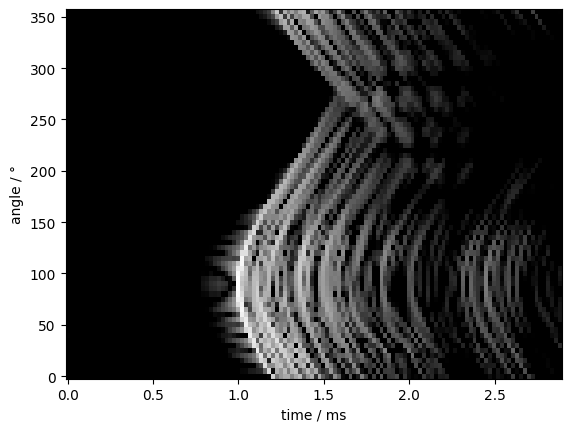

In [ ]:
t_lim_plot = 128
lim = -40

t_axis = np.arange(hrir_data_horizon.shape[2]) / fs * 1000
X, Y = np.meshgrid(t_axis[:t_lim_plot], hrir_angles)

data_log = np.abs(np.squeeze(hrir_data_horizon[:,0,:t_lim_plot]))

data_log = 20*np.log10(np.abs(np.squeeze(hrir_data_horizon[:,0,:t_lim_plot])))
data_log -= np.max(data_log)
data_log[data_log < lim] = lim
data_log = data_log

plt.figure()
plt.pcolormesh(X, Y, data_log, shading='auto', cmap="gray")
plt.xlabel("time / ms")
plt.ylabel("angle / °")


In [ ]:
np.where((hrir_angles >= 250) & (hrir_angles <= 27))[0]

array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])

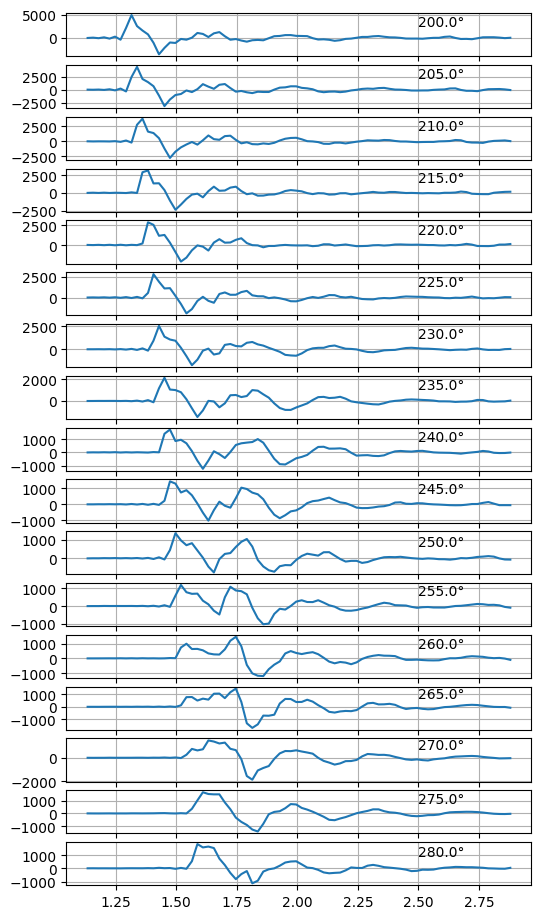

In [ ]:
contralat_angle_idx = np.where((hrir_angles >= 200) & (hrir_angles <= 280))[0]
# data_plot = data_log[contralat_angle_idx, :]
data_plot = np.squeeze(hrir_data_horizon[contralat_angle_idx,0])
plt.figure(figsize=(6, 12))

idx = 0
for ii in contralat_angle_idx:
    idx += 1
    plt.subplot(len(contralat_angle_idx) + 1, 1, idx)
    plt.plot(t_axis[50:128], np.squeeze(data_plot[idx-1, 50:128].T))
    plt.text(2.5, 0.5*np.max(data_plot[idx-1, 50:128]), f"{hrir_angles[ii]}°")
    plt.grid()